<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 11 </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [ ]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StanderdScaler
from sklearn.metrics import silhouette_score

# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [4]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# X = df[['math score', 'reading score']]

# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [6]:
df.info()
df.describe()
# df.

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Step 4: Display PairPlot

AttributeError: module 'matplotlib' has no attribute 'title'

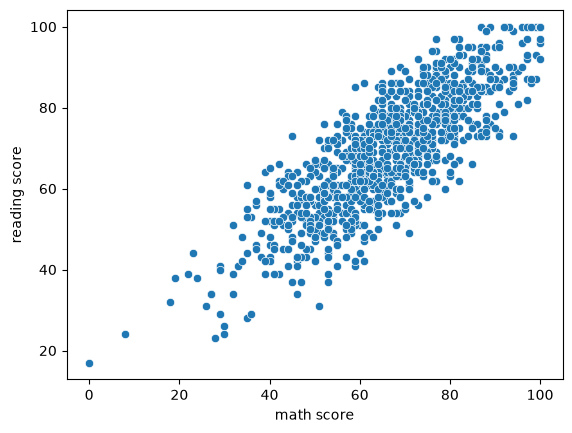

In [7]:
sns.scatterplot(
    x='math score',
    y='reading score',
    data=df
)

plt.title("Raw Data")
plt.show()

# Step 5: Correlation heatmap

# Step 6: Distribution of numerical features

# Step 7: Apply StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

: 

# Step 8: Elbow method to find optimal k

In [ ]:
WCSS = []
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), WCSS, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df[[
    'math score', 'reading score', 'writing score', 'Cluster'
]].head()

# Step 10: Print Cluster Center

In [ ]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

print(centers)

# Step 11: Plot Cluster

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['math score'],
    df['reading score'],
    c=df['Cluster'],
    cmap='viridis',
)

plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.title('K-Means Clustering Results')
plt.show()

# Step 12:Analyze clusters 

In [ ]:
cluster_analysis = df.groupby('Cluster')[[
    'math score',
    'reading score'
]].mean()

print(cluster_analysis)

# Step 13: Perform K-Medoids

# Step:14 Comparison of K-means and K-medoids Clusters

# Step: 15 | USE KMEAN++


In [ ]:
from sklearn.cluster import KMeans

kmeans1 = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

kmeans1.fit(X_scaled)

In [ ]:
labels = kmeans1.labels_
print(labels)